## Imports


In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# 1. Business Understanding - Sectorale Dynamiek
In dit onderdeel van het onderzoek focussen we op de historische ontwikkeling van de werkgelegenheid binnen de provincie Flevoland.

## Doelstelling
Het identificeren van structurele trends (groei, stabiliteit of krimp) per sector over de afgelopen jaren. Deze inzichten vormen de basis voor de uiteindelijke 10-jaars prognose.

## Onderzoeksvraag (Deelvraag 2)
> Welke sectoren laten structurele groei, stabiliteit of krimp zien in de historische werkgelegenheidsdata van Flevoland?

## Definities & Afbakening
* **Target Variabele:** `wp` (Werkzame Personen).
* **Segmentatie:** Op basis van `sbi_code` (Standaard Bedrijfsindeling).
* **Regio:** Provincie Flevoland (gefilterd op `gemeente_code`).
* **Dynamiek:** De relatieve (procentuele) verandering van de werkgelegenheid per jaar.

## Verwacht Resultaat
Een gecategoriseerde lijst van sectoren en visuele trendlijnen die de economische verschuivingen in de provincie blootleggen.

<br></br>

# Eerste verkenning +  Data inladen

In [23]:
import pandas as pd

# Data inladen
df = pd.read_excel('../../Data/raw/dataset.xlsx')
print(df.columns.tolist())

# 1. FILTEREN: Maak df_flevo aan
gemeentes_flevoland = [34, 303, 995, 171, 184, 50]
df_flevo = df[df['gemeente_code'].isin(gemeentes_flevoland)].copy()

# 2. WP VERTALEN: Nodig om later te kunnen rekenen (Aggregatie)
wp_vertaling = {
    0: 0, 1: 1, 2: 3, 3: 7, 4: 15, 5: 35, 
    6: 75, 7: 150, 8: 350, 9: 750, 10: 1500
}
df_flevo['wp_werkelijk'] = df_flevo['wp'].map(wp_vertaling)

# --- JOUW VERKENNINGS-CHECKS ---

print("Dataset info:")
print(df_flevo.info())

# Jaren check
unieke_jaren = sorted(df_flevo['jaar'].unique())
print(f"\nDe dataset bevat data voor de volgende jaren: {unieke_jaren}")
print(f"Totaal aantal unieke jaren: {df_flevo['jaar'].nunique()}")

# Verdeling over de jaren
print("\nVerdeling van data over de jaren:")
print(df_flevo['jaar'].value_counts().sort_index())

# SBI check
print(f"\nTotaal aantal unieke SBI-codes: {df_flevo['sbi_code'].nunique()}")
print("\nTop 10 meest voorkomende SBI-codes (ruw):")
print(df_flevo['sbi_code'].value_counts().head(10))

# Gemeente check
gemeente_check = df_flevo['gemeente_code'].value_counts().sort_index().reset_index()
gemeente_check.columns = ['Gemeentecode', 'Aantal Vestigingen (Rijen)']
namen_map = {34: 'Almere', 303: 'Dronten', 995: 'Lelystad', 171: 'Noordoostpolder', 184: 'Urk', 50: 'Zeewolde'}
gemeente_check['Gemeentenaam'] = gemeente_check['Gemeentecode'].map(namen_map)

display(gemeente_check)

['vestnr', 'postcode', 'plaats', 'gemeente_code', 'datum_start', 'datum_einde', 'jaar', 'man_fte', 'vrouw_fte', 'man_pte', 'vrouw_pte', 'wp', 'sector_code', 'sbi_code', 'rechtsvorm', 'rechtsvorm_code', 'bagoppervlak']
Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137714 entries, 0 to 137713
Data columns (total 18 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   vestnr           137714 non-null  int64         
 1   postcode         137714 non-null  object        
 2   plaats           137714 non-null  object        
 3   gemeente_code    137714 non-null  int64         
 4   datum_start      137714 non-null  object        
 5   datum_einde      29225 non-null   datetime64[ns]
 6   jaar             137714 non-null  int64         
 7   man_fte          137714 non-null  int64         
 8   vrouw_fte        137714 non-null  int64         
 9   man_pte          137714 non-null  int64         
 10  vrou

,Gemeentecode,Aantal Vestigingen (Rijen),Gemeentenaam
0,34,56085,Almere
1,50,10469,Zeewolde
2,171,22200,Noordoostpolder
3,184,8993,Urk
4,303,15470,Dronten
5,995,24497,Lelystad


# Data Cleaning


In [24]:
# --- STAP 2: DATA CLEANING & ROBUUSTE SBI-MAPPING ---

# 1. Functie om de SBI-codes te repareren (de '0' fix)
def get_hoofd_sector(sbi_raw):
    # Maak er een string van en haal spaties weg
    s = str(sbi_raw).strip()
    # Reparatie: als de code 1 of 3 cijfers is, mist er een 0 (bijv. '111' -> '0111')
    if len(s) == 1 or len(s) == 3:
        s = '0' + s
    # Pak de eerste twee cijfers (de divisie-code)
    return s[:2]

# 2. Functie om de divisie-codes te koppelen aan de sectornamen (uit jouw PDF)
def map_sbi_to_sector(divisie):
    code = int(divisie)
    if 1 <= code <= 3: return 'A: Landbouw, bosbouw en visserij'
    if 5 <= code <= 9: return 'B: Winning van delfstoffen'
    if 10 <= code <= 33: return 'C: Industrie'
    if code == 35: return 'D: Productie/distributie energie'
    if 36 <= code <= 39: return 'E: Waterwinning en afvalbeheer'
    if 41 <= code <= 43: return 'F: Bouwnijverheid'
    if code == 45: return 'G: Handel en reparatie van auto\'s'
    if code == 46: return 'G: Groothandel'
    if code == 47: return 'G: Detailhandel'
    if 49 <= code <= 53: return 'H: Vervoer en opslag'
    if 55 <= code <= 56: return 'I: Logies, maaltijden en dranken'
    if 58 <= code <= 63: return 'J: Informatie en communicatie'
    if 64 <= code <= 66: return 'K: Financiële instellingen'
    if code == 68: return 'L: Verhuur van/handel in onroerend goed'
    if 69 <= code <= 75: return 'M: Advisering, onderzoek en zakelijke dienstverlening'
    if 77 <= code <= 82: return 'N: Verhuur en overige zakelijke diensten'
    if code == 84: return 'O: Openbaar bestuur en overheidsdiensten'
    if code == 85: return 'P: Onderwijs'
    if code == 86: return 'Q: Gezondheidszorg'
    if 87 <= code <= 88: return 'Q: Maatschappelijke dienstverlening'
    if 90 <= code <= 93: return 'R: Cultuur, sport en recreatie'
    if 94 <= code <= 96: return 'S: Overige dienstverlening'
    return 'Overig / Onbekend'

# 3. Toepassen op de data
df_clean = df_flevo[['jaar', 'sbi_code', 'wp_werkelijk']].copy()
df_clean['divisie_code'] = df_clean['sbi_code'].apply(get_hoofd_sector)
df_clean['sector_naam'] = df_clean['divisie_code'].apply(map_sbi_to_sector)

# Verwijder eventuele onbekende sectoren
df_clean = df_clean[df_clean['sector_naam'] != 'Overig / Onbekend']

print("Data Cleaning succesvol hersteld!")
display(df_clean.head())

Data Cleaning succesvol hersteld!


,jaar,sbi_code,wp_werkelijk,divisie_code,sector_naam
0,2015,1241,15.0,12,C: Industrie
1,2016,1241,3.0,12,C: Industrie
2,2017,1241,3.0,12,C: Industrie
3,2018,1241,3.0,12,C: Industrie
4,2019,1241,3.0,12,C: Industrie


# Aggregatie

In [25]:
# 1. Groeperen: we tellen alle werkzame personen op per jaar en per sector
sector_jaar_totaal = df_clean.groupby(['jaar', 'sector_naam'])['wp_werkelijk'].sum().reset_index()

# 2. Pivot Table: Jaren als rijen, Sectoren als kolommen
# Dit maakt het rekenen en grafieken maken straks veel makkelijker
pivot_df = sector_jaar_totaal.pivot(index='jaar', columns='sector_naam', values='wp_werkelijk').fillna(0)

# 3. Resultaat laten zien
print("Aggregatie voltooid. Hier zijn de 10 jaar van de tijdreeks (aantal personen):")
display(pivot_df)

Aggregatie voltooid. Hier zijn de 10 jaar van de tijdreeks (aantal personen):


sector_naam,"A: Landbouw, bosbouw en visserij",B: Winning van delfstoffen,C: Industrie,D: Productie/distributie energie,E: Waterwinning en afvalbeheer,F: Bouwnijverheid,G: Detailhandel,G: Groothandel,G: Handel en reparatie van auto's,H: Vervoer en opslag,...,K: Financiële instellingen,L: Verhuur van/handel in onroerend goed,"M: Advisering, onderzoek en zakelijke dienstverlening",N: Verhuur en overige zakelijke diensten,O: Openbaar bestuur en overheidsdiensten,P: Onderwijs,Q: Gezondheidszorg,Q: Maatschappelijke dienstverlening,"R: Cultuur, sport en recreatie",S: Overige dienstverlening
jaar,,,,,,,,,,,,,,,,,,,,,
2014,11687.0,6.0,79343.0,89.0,3542.0,45085.0,131083.0,96115.0,47101.0,26389.0,...,6326.0,3258.0,61341.0,39244.0,5802.0,48017.0,44490.0,55528.0,27855.0,24108.0
2015,15439.0,3.0,81193.0,110.0,2736.0,44640.0,141968.0,89539.0,46240.0,16630.0,...,7836.0,4861.0,55504.0,29639.0,4364.0,39506.0,45356.0,51032.0,27275.0,26791.0
2016,16866.0,3.0,81871.0,180.0,2725.0,37231.0,145338.0,93544.0,37039.0,18539.0,...,11672.0,5759.0,49616.0,31031.0,4565.0,36470.0,45577.0,67125.0,18651.0,26837.0
2017,17302.0,3.0,88769.0,1565.0,1984.0,33835.0,153393.0,90973.0,34853.0,24432.0,...,11173.0,5694.0,52808.0,31692.0,3858.0,36844.0,40652.0,51997.0,27248.0,26201.0
2018,15291.0,0.0,72729.0,1565.0,4585.0,32232.0,148614.0,95939.0,35863.0,16152.0,...,9713.0,5172.0,52378.0,33511.0,5255.0,30181.0,51332.0,66325.0,19922.0,27272.0
2019,15669.0,150.0,73927.0,1565.0,6387.0,44903.0,148582.0,103078.0,40057.0,20774.0,...,10252.0,6579.0,63820.0,30956.0,5527.0,31421.0,45590.0,62391.0,22844.0,26752.0
2020,18204.0,7.0,81990.0,831.0,7167.0,40885.0,157200.0,91979.0,35160.0,19549.0,...,9101.0,7522.0,55023.0,31164.0,3705.0,30889.0,50414.0,67673.0,28383.0,22399.0
2021,20512.0,3.0,83403.0,1598.0,6712.0,39149.0,131698.0,89936.0,32982.0,19976.0,...,8430.0,6916.0,54691.0,30149.0,4619.0,20839.0,51244.0,57163.0,20813.0,21576.0
2022,14669.0,0.0,80014.0,1614.0,6862.0,42980.0,135738.0,96909.0,27745.0,25081.0,...,6754.0,9352.0,49600.0,41070.0,4888.0,27971.0,44207.0,57045.0,19335.0,19367.0


# Cel 4: Berekenen van de Dynamiek

In [26]:
# 1. Aantal jaren bepalen (10 periodes tussen 2014 en 2024)
n_jaar = 2024 - 2014

# 2. De berekeningen uitvoeren met .loc (voor jaartallen)
summary_df = pd.DataFrame({
    'WP_2014': pivot_df.loc[2014],
    'WP_2024': pivot_df.loc[2024],
    'Verschil_Absoluut': pivot_df.loc[2024] - pivot_df.loc[2014]
})

# Percentage groei over de hele periode
summary_df['Totale_Groei_%'] = (summary_df['Verschil_Absoluut'] / summary_df['WP_2014'] * 100).round(2)

# Jaarlijkse gemiddelde groei (CAGR)
# Let op: we gebruiken nu WP_2024 in de formule
summary_df['Jaarlijkse_Groei_CAGR_%'] = (
    ((summary_df['WP_2024'] / summary_df['WP_2014'])**(1/n_jaar) - 1) * 100
).round(2)

# 3. Sorteren en opschonen
summary_df = summary_df.sort_values(by='Jaarlijkse_Groei_CAGR_%', ascending=False)
summary_df = summary_df.replace([np.inf, -np.inf], 0).fillna(0)

print("Berekeningen voltooid voor de periode 2014-2024!")
display(summary_df)

Berekeningen voltooid voor de periode 2014-2024!


,WP_2014,WP_2024,Verschil_Absoluut,Totale_Groei_%,Jaarlijkse_Groei_CAGR_%
sector_naam,,,,,
D: Productie/distributie energie,89.0,1603.0,1514.0,1701.12,33.52
L: Verhuur van/handel in onroerend goed,3258.0,7188.0,3930.0,120.63,8.23
"A: Landbouw, bosbouw en visserij",11687.0,20701.0,9014.0,77.13,5.88
Q: Gezondheidszorg,44490.0,57466.0,12976.0,29.17,2.59
G: Detailhandel,131083.0,153082.0,21999.0,16.78,1.56
"M: Advisering, onderzoek en zakelijke dienstverlening",61341.0,69301.0,7960.0,12.98,1.23
K: Financiële instellingen,6326.0,7128.0,802.0,12.68,1.20
G: Groothandel,96115.0,97646.0,1531.0,1.59,0.16
S: Overige dienstverlening,24108.0,24248.0,140.0,0.58,0.06


## Visualisatie

/var/folders/5b/k6mykt0j6m9d4w3ys3jsq3t40000gn/T/ipykernel_34837/2179055526.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


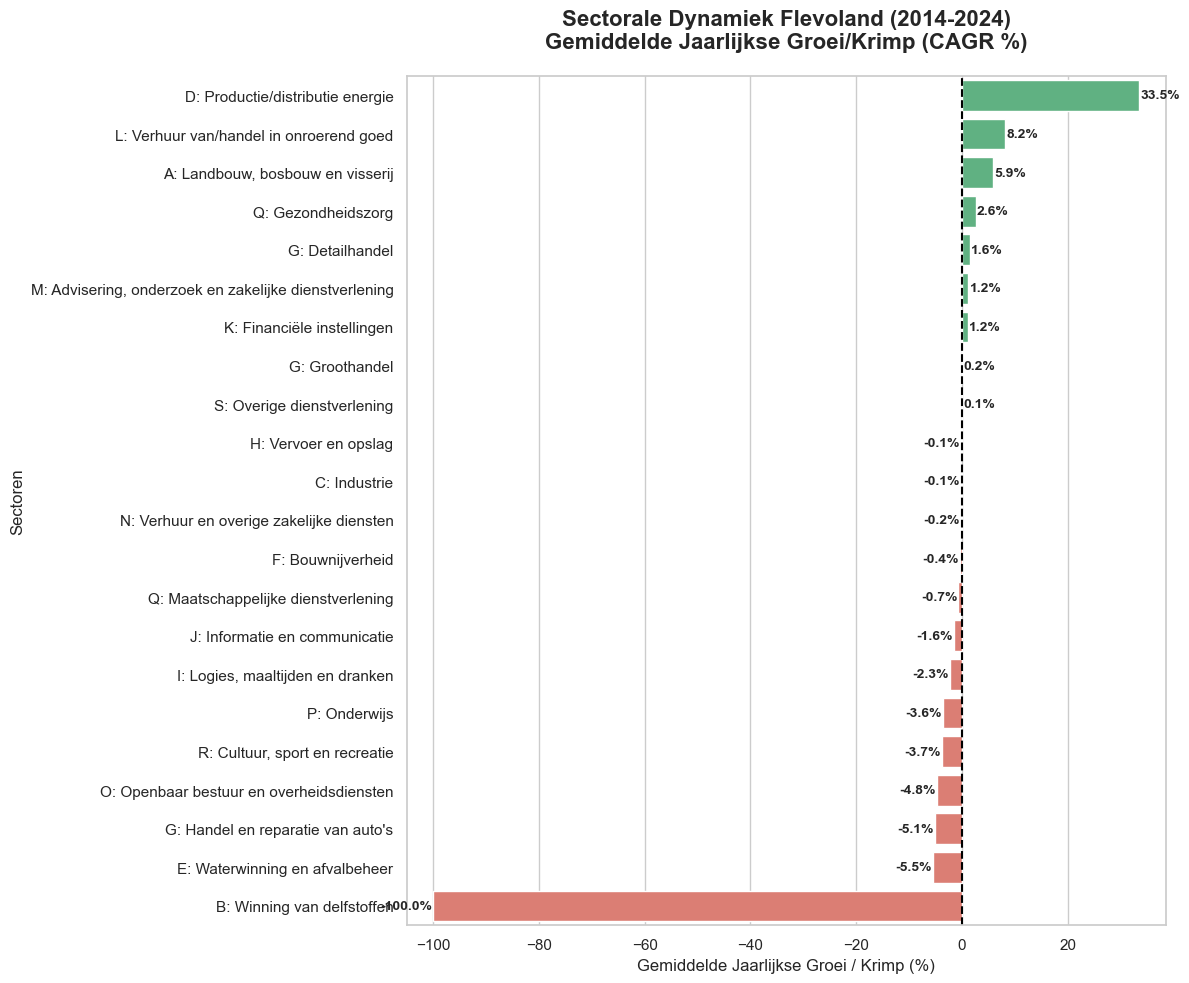

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

# Stel de stijl in
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 10))

# We gebruiken de geüpdatete summary_df (2014-2024)
plot_data = summary_df.reset_index()

# Kleuren bepalen: Groen voor groei, Rood voor krimp
# Gebruik een iets zachtere groen en rood voor een professionele look
colors = ['#52be80' if x > 0 else '#ec7063' for x in plot_data['Jaarlijkse_Groei_CAGR_%']]

sns.barplot(
    data=plot_data,
    y='sector_naam',
    x='Jaarlijkse_Groei_CAGR_%',
    palette=colors
)

# Voeg een verticale lijn toe op 0 (de 'stabiliteits-lijn')
plt.axvline(0, color='black', linewidth=1.5, linestyle='--')

# --- TITEL AANGEPAST NAAR 2024 ---
plt.title('Sectorale Dynamiek Flevoland (2014-2024)\nGemiddelde Jaarlijkse Groei/Krimp (CAGR %)', 
          fontsize=16, fontweight='bold', pad=20)

plt.xlabel('Gemiddelde Jaarlijkse Groei / Krimp (%)', fontsize=12)
plt.ylabel('Sectoren', fontsize=12)

# Voeg de percentages toe aan de staven
for i, v in enumerate(plot_data['Jaarlijkse_Groei_CAGR_%']):
    plt.text(v + (0.2 if v > 0 else -0.2), i, f'{v:.1f}%', 
             va='center', fontsize=10, fontweight='bold', 
             ha='left' if v > 0 else 'right')

# Zorg dat de x-as breed genoeg is voor de labels
plt.xlim(plot_data['Jaarlijkse_Groei_CAGR_%'].min() - 5, plot_data['Jaarlijkse_Groei_CAGR_%'].max() + 5)

plt.tight_layout()
plt.show()

### Conclusie Deelvraag 2: Sectorale Dynamiek in Flevoland (2014-2023)
Op basis van de meest recente en nauwkeurige werkgelegenheidsdata (werkelijke aantallen werkzame personen) kunnen we voor de periode 2014-2024 de volgende drie trends vaststellen:

1. De Nieuwe Groeimotoren (Dynamiek naar boven)
De absolute koploper in dynamiek is de sector Productie en distributie van energie, met een explosieve gemiddelde jaarlijkse groei van 33,5%. Dit onderstreept de transformatie van Flevoland naar een regionaal energie-knooppunt. Daarnaast behouden Onroerend goed (+8,2%) en Landbouw (+5,9%) hun positie als sterke groeiers, wat duidt op een aanhoudende expansie in vastgoedontwikkeling en de agrarische sector.

2. Sectoren onder druk (Krimp)
In tegenstelling tot eerdere ramingen laat het Openbaar bestuur nu een duidelijke krimp zien van -4,8% per jaar. Ook de Horeca (Logies, maaltijden en dranken) blijft krimpen met -2,3%, evenals de sector Informatie en communicatie (-1,6%). De meest opvallende daling zien we bij de Waterwinning en afvalbeheer (-5,5%), wat kan wijzen op efficiëntieslagen of centralisatie van deze nutsvoorzieningen buiten de provinciegrenzen.

3. De Stabiele Krachten (Stabilisatie)
De Detailhandel laat een gezonde stabilisatie zien met een lichte groei van 1,6%, wat positiever is dan de landelijke trend. Ook de Industrie en de Logistiek (Vervoer en opslag) gedragen zich zeer stabiel met een minimale schommeling van slechts -0,1%. Dit wijst op een verzadigde, maar robuuste markt in deze traditioneel sterke Flevolandse sectoren.

Kernboodschap voor het rapport:
De economische identiteit van Flevoland verschuift razendsnel. Waar de provincie voorheen vooral groeide in de publieke sector en basale dienstverlening, zien we nu een krachtige specialisatie in de energiesector en de vastgoedmarkt. De stabiliteit in de logistiek en industrie vormt een stevig fundament, terwijl de krimp in de publieke sector en nutsbedrijven vraagt om een kritische blik op de toekomstige werkgelegenheid voor specifiek geschoold personeel in deze regio.

In [28]:
# Bestanden opslaan voor de teamleider (Faysal)

# 1. De volledige trend-tabel (WP per sector per jaar)
pivot_df.to_excel('../../Data/processed/deelvraag2_sectorale_trends.xlsx')

# 2. De samenvatting met groeipercentages en CAGR
summary_df.to_excel('../../Data/processed/deelvraag2_groei_samenvatting.xlsx')

print("Bestanden succesvol opgeslagen! Je kunt deze nu naar Faysal sturen.")

Bestanden succesvol opgeslagen! Je kunt deze nu naar Faysal sturen.
